# Analise Exploratória de Dados

#### Imortanto lib e Carregando o dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
df = pd.read_parquet(
    'dataset_gold.parquet',
    engine='fastparquet'
)
df.head()

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,price,preco_usd,tempo_total_horas,custo_hora,owners_medio,steam_rating,custo_hora_norm,steam_rating_norm,score_cb,retencao,hidden_gem
0,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",3854,835,2999,29.99,64.23,0.47,75000000.0,0.9410,0.0005,0.9307,0.9651,0.2167,0
1,1938090,Call of Duty: Modern Warfare II,"Treyarch, Raven Software, Beenox, High Moon St...",Activision,419594,294520,"50,000,000 .. 100,000,000",5397,639,3849,38.49,89.95,0.43,75000000.0,0.5876,0.0004,0.5156,0.7576,0.1184,0
2,1063730,New World: Aeternum,Amazon Games,Amazon Games,196798,90080,"50,000,000 .. 100,000,000",10588,18,5999,59.99,176.47,0.34,75000000.0,0.6860,0.0003,0.6312,0.8154,0.0017,0
3,2358720,Black Myth: Wukong,Game Science,Game Science,1111720,38378,"50,000,000 .. 100,000,000",3268,524,5999,59.99,54.47,1.10,75000000.0,0.9666,0.0011,0.9608,0.9798,0.1603,0
4,550,Left 4 Dead 2,Valve,Valve,940221,23762,"50,000,000 .. 100,000,000",2479,352,999,9.99,41.32,0.24,75000000.0,0.9754,0.0002,0.9711,0.9854,0.1420,0


## Visão Geral do Dataset

### Resumo estatístico

A seguir apresentamos as principais estatísticas descritivas do dataset para as variáveis centrais da análise. O objetivo é ter uma visão geral da amplitude e dispersão dos dados antes de responder às questões de pesquisa.

In [3]:
df.describe()

,appid,positive,negative,average_forever,average_2weeks,price,preco_usd,tempo_total_horas,custo_hora,owners_medio,steam_rating,custo_hora_norm,steam_rating_norm,score_cb,retencao,hidden_gem
count,7.166000e+03,7.166000e+03,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7.166000e+03,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000,7166.000000
mean,8.312383e+05,1.291433e+04,1730.454507,1029.250768,106.659085,1504.619732,15.046197,17.154219,2.972019,8.811471e+05,0.805824,0.002977,0.771933,0.884479,0.106564,0.071867
std,7.028078e+05,5.729950e+04,8188.610636,4235.226678,381.956677,1324.385895,13.243859,70.587130,16.574439,3.067683e+06,0.141401,0.016582,0.166081,0.083834,0.392711,0.258286
min,1.000000e+01,2.000000e+00,0.000000,1.000000,0.000000,27.000000,0.270000,0.020000,0.000000,7.500000e+04,0.148600,0.000000,0.000000,0.177600,0.000000,0.000000
25%,3.063800e+05,6.960000e+02,150.000000,218.000000,0.000000,499.000000,4.990000,3.630000,0.610000,1.500000e+05,0.738325,0.000600,0.692625,0.844600,0.000000,0.000000
50%,5.729750e+05,2.024500e+03,354.500000,387.000000,0.000000,999.000000,9.990000,6.450000,1.430000,3.500000e+05,0.841200,0.001400,0.813500,0.905400,0.000000,0.000000
75%,1.225568e+06,6.252750e+03,971.000000,907.000000,41.000000,1999.000000,19.990000,15.120000,2.970000,7.500000e+05,0.911600,0.003000,0.896200,0.946875,0.049800,0.000000
max,3.431040e+06,1.373979e+06,294520.000000,263340.000000,9872.000000,14999.000000,149.990000,4389.000000,999.500000,7.500000e+07,1.000000,1.000000,1.000000,0.999400,10.884200,1.000000


### Contagem de jogos por faixa de preço

##### Faixa de Preço

Para facilitar a comparação de custo-benefício entre os jogos, categorizamos
o preço em quatro faixas baseadas no valor em dólares:

| Faixa | Intervalo |
|-------|-----------|
| Até \$5 | jogos de entrada, geralmente indies |
| \$5–\$15 | faixa intermediária mais popular |
| \$15–\$30 | títulos mid-range |
| Acima de \$30 | jogos premium e AAA |

A contagem abaixo mostra como os jogos se distribuem entre as faixas,
revelando quais segmentos de preço dominam o catálogo analisado.

In [4]:

bins   = [0, 5, 15, 30, float('inf')]
labels = ['Até $5', '$5–$15', '$15–$30', 'Acima de $30']

df['faixa_preco'] = pd.cut(
    df['preco_usd'],
    bins=bins,
    labels=labels,
    right=False
)

print(df['faixa_preco'].value_counts())

faixa_preco
$5–$15          2583
Até $5          2019
$15–$30         1941
Acima de $30     623
Name: count, dtype: int64


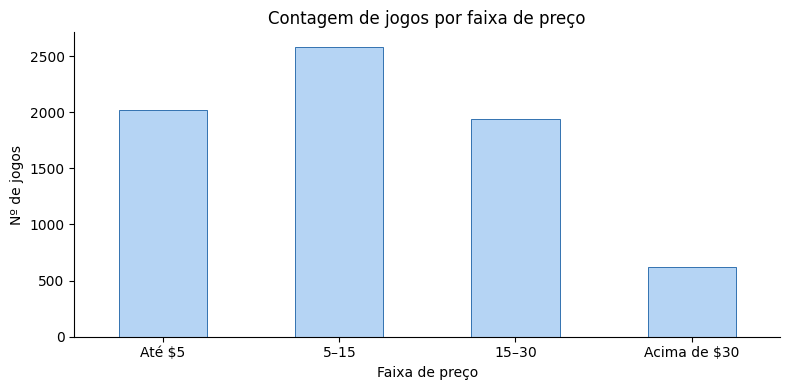

In [5]:
contagem = df['faixa_preco'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4))
contagem.plot(kind='bar', ax=ax, color='#B5D4F4',
              edgecolor='#185FA5', linewidth=0.6)

ax.set_xlabel('Faixa de preço')
ax.set_ylabel('Nº de jogos')
ax.set_title('Contagem de jogos por faixa de preço')
ax.set_xticklabels(labels, rotation=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

O gráfico mostra que a faixa ```$5–$15``` concentra o maior número de jogos (2.583 títulos), seguida de perto por ```Até $5``` (2.019) e ```$15–$30``` (1.941). Juntas, essas três faixas representam cerca de 92% do catálogo analisado. Os jogos ```Acima de $30``` são minoria, com apenas 623 títulos — o que reflete o perfil acessível da plataforma Steam.

### Distribuição do ```score_cb```

Antes de comparar os jogos entre si, é importante entender como o `score_cb` se distribui no conjunto analisado. O histograma abaixo mostra se os jogos  estão espalhados de forma equilibrada ou concentrados em um intervalo estreito
— o que impacta diretamente a qualidade das comparações nas seções seguintes.

As linhas tracejadas marcam os percentis **P25**, **P50** e **P75**, que serão usados como limiares nas análises de Q1 e Q2. Em especial, o **P75** define o critério de "alto custo-benefício" na identificação das hidden gems.

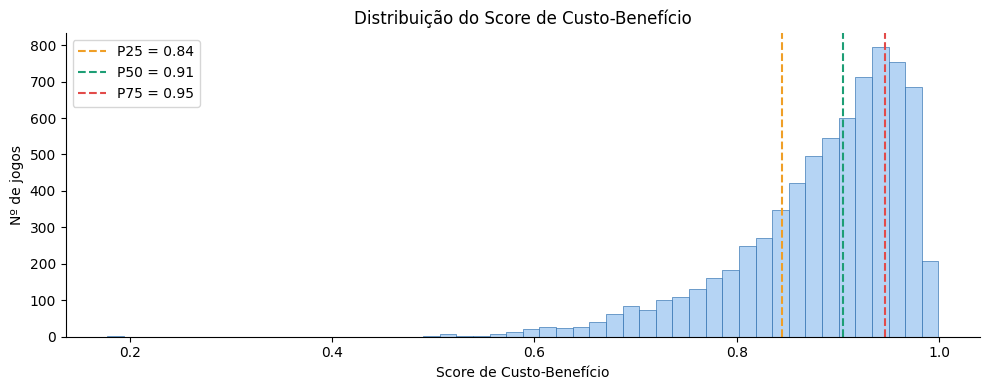

In [6]:
p25 = df['score_cb'].quantile(0.25)
p50 = df['score_cb'].quantile(0.50)
p75 = df['score_cb'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df['score_cb'].dropna(), bins=50,
        color='#B5D4F4', edgecolor='#185FA5', linewidth=0.4)

ax.axvline(p25, color='#EF9F27', linestyle='--', linewidth=1.5, label=f'P25 = {p25:.2f}')
ax.axvline(p50, color='#1D9E75', linestyle='--', linewidth=1.5, label=f'P50 = {p50:.2f}')
ax.axvline(p75, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'P75 = {p75:.2f}')

ax.set_xlabel('Score de Custo-Benefício')
ax.set_ylabel('Nº de jogos')
ax.set_title('Distribuição do Score de Custo-Benefício')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

O histograma revela uma distribuição assimétrica à esquerda, com a grande maioria dos jogos concentrada entre 0,80 e 1,0. Os três percentis estão comprimidos nesse intervalo P25 = 0,84, P50 = 0,91 e P75 = 0,95, o que indica que diferenças de 0,05 no score já são relevantes para distinguir jogos nesse dataset. Nesse contexto, um jogo com score abaixo de 0,84 já pode ser considerado abaixo do padrão do catálogo analisado.

A cauda esquerda é longa mas esparsa: jogos com score abaixo de 0,50 existem, mas são exceções, títulos caros, mal avaliados e com pouco tempo de jogo. Essa concentração nos valores altos reflete um viés de seleção natural do Steam Spy, onde jogos muito ruins tendem a desaparecer dos registros ao longo do tempo.

Por fim, o pico da distribuição está ligeiramente acima da mediana (por volta de 0,93) indicando que o jogo "típico" do dataset já apresenta bom custo-benefício. Isso é um contexto importante para as análises seguintes: identificar jogos com custo-benefício superior à média exige olhar para a faixa acima de 0,95, onde está o quartil mais seleto do catálogo.

### Tabela de resumo das métricas-chave

A tabela abaixo apresenta média e mediana das principais métricas do dataset e serve como referência para interpretar os gráficos e comparações ao longo da análise.

In [8]:
resumo = pd.DataFrame({
    'Métrica': ['preco_usd', 'custo_hora', 'steam_rating', 'score_cb'],
    'Média':   [df['preco_usd'].mean(),    df['custo_hora'].mean(),
                df['steam_rating'].mean(), df['score_cb'].mean()],
    'Mediana': [df['preco_usd'].median(),  df['custo_hora'].median(),
                df['steam_rating'].median(), df['score_cb'].median()]
}).set_index('Métrica').round(2)

display(resumo)

,Média,Mediana
Métrica,,
preco_usd,15.05,9.99
custo_hora,2.97,1.43
steam_rating,0.81,0.84
score_cb,0.88,0.91


- **Preço (`preco_usd`):** a mediana de $9,99 indica que metade dos jogos custa até $10, mas a média de $15,05 revela que jogos mais caros puxam o valor para cima, o que confirma a assimetria já observada na distribuição de preços.

- **Custo por hora (`custo_hora`):** a mediana de $1,43/hora mostra que, para a maioria dos jogos, o custo por hora jogada é bastante acessível. A média de $2,97 (mais que o dobro da mediana) indica que uma minoria de jogos caros e com pouco tempo de jogo distorce significativamente esse indicador.

- **Steam Rating (`steam_rating`):** tanto média (0,81) quanto mediana (0,84) estão acima de 0,80, o que significa que o catálogo analisado é majoritariamente bem avaliado. Nesse contexto, um jogo com rating abaixo de 0,70 pode ser considerado um outlier negativo relevante.

- **Score de Custo-Benefício (`score_cb`):** média de 0,88 e mediana de 0,91 indicam que a distribuição está concentrada nos valores mais altos da escala. Isso sugere que o dataset, por ser composto de jogos pagos com avaliações disponíveis, já representa uma seleção naturalmente positiva. Jogos muito ruins tendem a ser abandonados e desaparecem dos registros do Steam Spy.

## Q1: Custo-Benefício por faixa de preço

A relação entre preço, tempo médio de jogo e avaliação dos usuários permite identificar diferenças claras de custo-benefício entre os títulos pagos na Steam?

### Custo por Hora Jogada por Faixa de Preço

O gráfico utiliza **escala logarítmica** no eixo Y pois o `custo_hora` apresenta outliers extremos, pois alguns jogos chegam a $500–$1000 por hora, enquanto a maioria fica abaixo de $5,00. Em escala linear, esses valores extremos comprimiriam todas as caixas na base do gráfico, tornando a comparação entre faixas impossível. A escala log preserva todos os dados visíveis e permite comparar as distribuições com clareza, omde cada intervalo no eixo representa uma multiplicação por 10 ($0,01 → $0,10 → $1,00 → $10,00 → $100,00), e não uma soma.

**O que o gráfico revela:**

- **Até $5** apresenta a melhor mediana de custo por hora (~$0,60/hora), significativamente menor que as demais faixas. Jogos baratos tendem a ser indies com grande volume de horas de jogo, o que resulta num custo por hora muito competitivo.

- **$5–$15, $15–$30 e Acima de $30** apresentam medianas muito similares entre si (~$2,00/hora), indicando que pagar mais pelo jogo não necessariamente aumenta o custo por hora. Jogos mais caros também tendem a oferecer mais horas de conteúdo.

- **Outliers em vermelho** aparecem em todas as faixas e representam jogos com poucas horas de jogo em relação ao preço cobrado, ou seja, os casos de pior custo-benefício do dataset, independente da faixa de preço.

C:\Users\woqua\AppData\Local\Temp\ipykernel_15000\4258655693.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos,


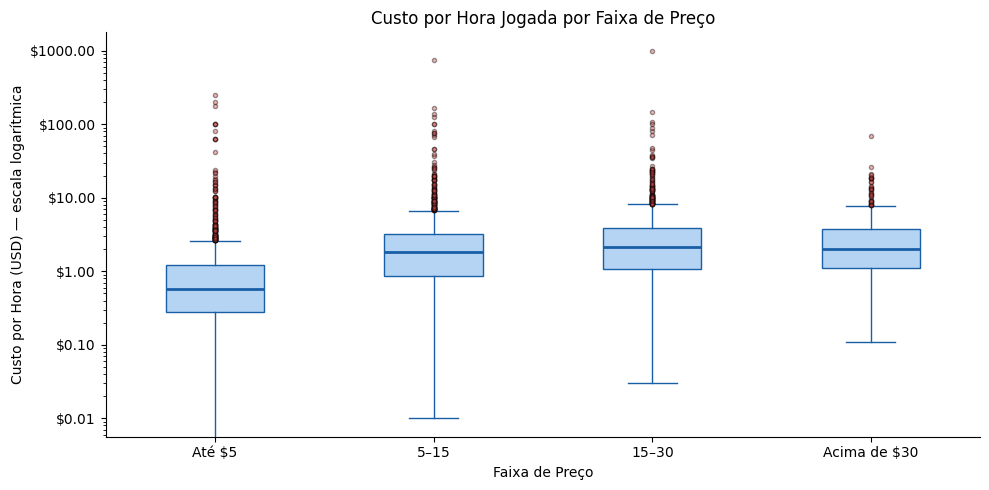

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

grupos = [df[df['faixa_preco'] == faixa]['custo_hora'].dropna()
          for faixa in labels]

ax.boxplot(grupos,
           labels=labels,
           patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
           medianprops=dict(color='#185FA5', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#E24B4A',
                           markersize=3, alpha=0.4, linestyle='none'),
           whiskerprops=dict(color='#185FA5'),
           capprops=dict(color='#185FA5'))

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))

ax.set_xlabel('Faixa de Preço')
ax.set_ylabel('Custo por Hora (USD) — escala logarítmica')
ax.set_title('Custo por Hora Jogada por Faixa de Preço')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Steam Rating por Faixa de Preço


O `steam_rating` vai de 0 a 1 por definição, os dados se comportam dentro de um intervalo controlado e as caixas são diretamente comparáveis.

**O que o gráfico revela:**

- **Até $5** apresenta a maior variação de qualidade, a caixa é visivelmente mais larga, com Q1 próximo de 0,70 e mediana em torno de 0,81. Isso indica que jogos baratos são mais inconsistentes em qualidade: há ótimos indies bem avaliados, mas também muitos títulos de baixa qualidade nessa faixa.

- **$5–$15, $15–$30 e Acima de $30** apresentam caixas mais compactas e medianas similares (~0,84–0,85), sugerindo que jogos a partir de $5,00 tendem a ter qualidade mais homogênea e consistentemente bem avaliada.

- **Outliers em vermelho** aparecem na parte inferior de todas as faixas. Jogos mal avaliados existem em qualquer faixa de preço, mas são minoria. Chama atenção que as faixas $5–$15 e $15–$30 possuem outliers chegando a ~0,20, indicando que pagar mais não garante qualidade.

- De forma geral, o `steam_rating` **não apresenta diferenças expressivas entre as faixas de preço** o que sugere que o preço não é um bom preditor de qualidade percebida pelo jogador.


C:\Users\woqua\AppData\Local\Temp\ipykernel_15000\1737940602.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos,


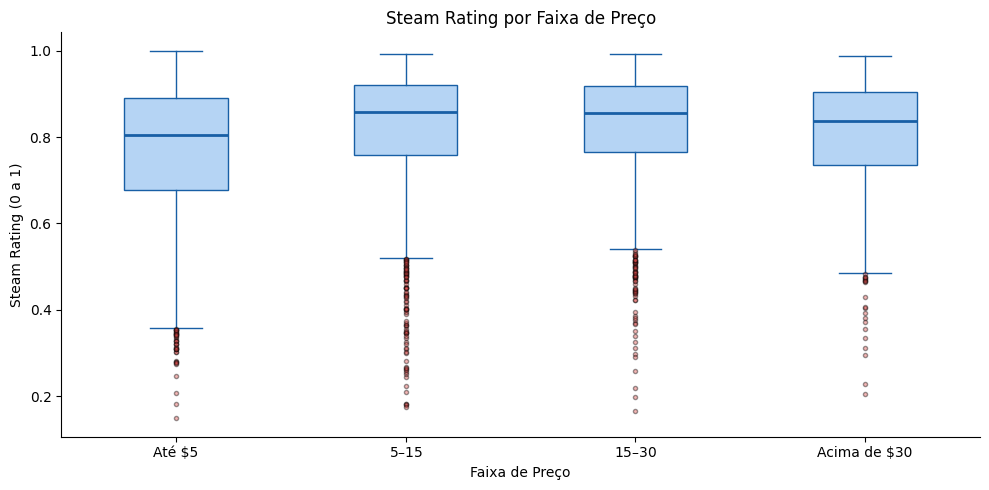

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

grupos = [df[df['faixa_preco'] == faixa]['steam_rating'].dropna()
          for faixa in labels]

ax.boxplot(grupos,
           labels=labels,
           patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
           medianprops=dict(color='#185FA5', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#E24B4A',
                           markersize=3, alpha=0.4, linestyle='none'),
           whiskerprops=dict(color='#185FA5'),
           capprops=dict(color='#185FA5'))

ax.set_xlabel('Faixa de Preço')
ax.set_ylabel('Steam Rating (0 a 1)')
ax.set_title('Steam Rating por Faixa de Preço')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Score de Custo-Benefício por Faixa de Preço

Este é o gráfico central da Q1, pois o `score_cb` combina em um único indicador o custo por hora e o steam_rating, permitindo comparar o valor percebido entre as faixas de forma objetiva.

**O que o gráfico revela:**

- **Até $5** apresenta a maior variação de score, a caixa é mais larga e o bigode inferior chega a ~0,60, o que reflete o que já observamos nos gráficos anteriores: jogos baratos são mais inconsistentes, com ótimos títulos indie lado a lado com jogos de baixa qualidade e poucas horas de jogo.

- **$5–$15 e $15–$30** apresentam as melhores medianas (~0,90–0,91) e caixas mais compactas, indicando que essa é a faixa com melhor equilíbrio entre preço, horas de jogo e avaliação, indicando o "ponto ideal" de custo-benefício no catálogo analisado.

- **Acima de $30** mantém mediana similar (~0,90) mas com caixa ligeiramente mais larga que as faixas intermediárias, sugerindo maior variação. Alguns jogos premium entregam muito valor, outros nem tanto.

- O único outlier abaixo de 0,20 aparece na faixa **$15–$30**, provavelmente um jogo caro, mal avaliado e com poucas horas de jogo, o pior caso do dataset.

**Conclusão para Q1:** os dados sustentam **H1** — existem diferenças observáveis de custo-benefício entre as faixas, especialmente quando comparamos **Até $5** com as faixas intermediárias. A faixa **$5–$15** se destaca como a mais consistente em termos de valor entregue ao jogador.

C:\Users\woqua\AppData\Local\Temp\ipykernel_15000\637287641.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grupos,


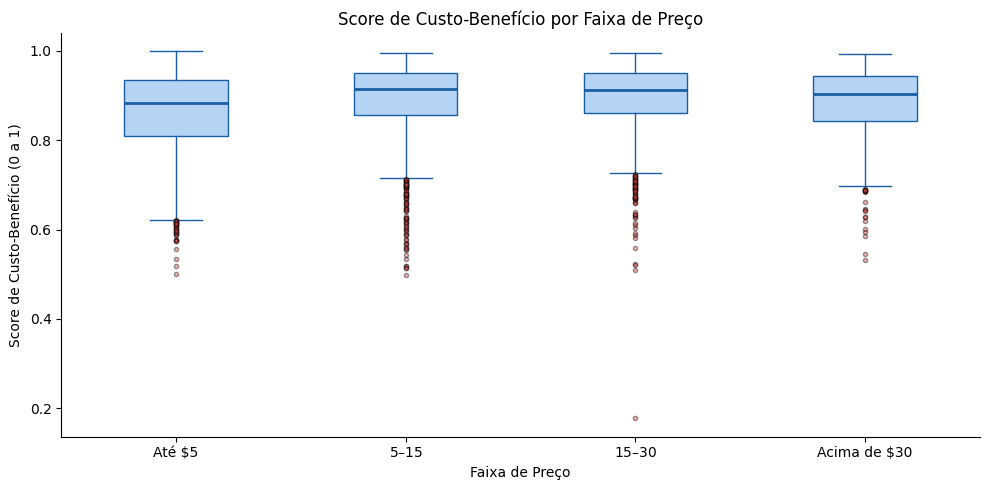

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

grupos = [df[df['faixa_preco'] == faixa]['score_cb'].dropna()
          for faixa in labels]

ax.boxplot(grupos,
           labels=labels,
           patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
           medianprops=dict(color='#185FA5', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#E24B4A',
                           markersize=3, alpha=0.4, linestyle='none'),
           whiskerprops=dict(color='#185FA5'),
           capprops=dict(color='#185FA5'))

ax.set_xlabel('Faixa de Preço')
ax.set_ylabel('Score de Custo-Benefício (0 a 1)')
ax.set_title('Score de Custo-Benefício por Faixa de Preço')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Tabela Comparativa por Faixa de Preço

A tabela consolida as três métricas principais por faixa de preço e permite comparar média e mediana lado a lado, confirmando visualmente o que os boxplots já sinalizavam.

**Custo por Hora:**
a faixa **Até $5** tem a menor mediana ($0,58/hora), mas sua média é $1,68, distância essa que confirma a presença de outliers puxando para cima. As faixas **$5–$15** e **$15–$30** têm medianas mais altas ($1,81 e $2,12), porém mais consistentes. Vale notar que **Acima de $30** ($2,00) fica abaixo de **$15–$30** na mediana, o que pode significar que jogos premium tendem a ser longos o suficiente para compensar o preço maior.

**Steam Rating:**
as diferenças entre faixas são pequenas, todas as medianas ficam entre 0,80 e 0,86. A faixa **Até $5** tem a menor mediana (0,80), reforçando que jogos muito baratos são mais inconsistentes em qualidade. As faixas intermediárias ($5–$15 e $15–$30) lideram com 0,86 e 0,85.

**Score de Custo-Benefício:**
as medianas variam entre 0,88 e 0,91, intervalo estreito que confirma a concentração do dataset nos valores altos. A faixa **$5–$15** e **$15–$30** empatam na melhor mediana (0,91), enquanto **Até $5** fica com a menor (0,88), penalizada pelo custo por hora mais variável.

**Conclusão:** a tabela reforça H1 — existem diferenças observáveis entre as faixas, mesmo que sutis. O melhor custo-benefício consistente está nas faixas intermediárias, especialmente **$5–$15**, que combina boa avaliação, custo por hora razoável e menor variação entre os jogos.

In [17]:
tabela = df.groupby('faixa_preco', observed=True).agg(
    custo_hora_media=('custo_hora', 'mean'),
    custo_hora_mediana=('custo_hora', 'median'),
    steam_rating_media=('steam_rating', 'mean'),
    steam_rating_mediana=('steam_rating', 'median'),
    score_cb_media=('score_cb', 'mean'),
    score_cb_mediana=('score_cb', 'median')
).round(2).reindex(labels)

tabela.columns = pd.MultiIndex.from_tuples([
    ('Custo por Hora', 'Média'),
    ('Custo por Hora', 'Mediana'),
    ('Steam Rating', 'Média'),
    ('Steam Rating', 'Mediana'),
    ('Score CB', 'Média'),
    ('Score CB', 'Mediana')
])

display(tabela)

Custo por Hora         Steam Rating         Score CB        
                      Média Mediana        Média Mediana    Média Mediana
faixa_preco                                                              
Até $5                 1.68    0.58         0.77    0.80     0.86    0.88
$5–$15                 3.22    1.81         0.82    0.86     0.89    0.91
$15–$30                3.93    2.12         0.83    0.85     0.90    0.91
Acima de $30           3.13    2.00         0.80    0.84     0.88    0.90

### Conclusão — Q1

Os dados analisados sustentam **H1**: existem diferenças observáveis de custo-benefício entre as faixas de preço, especialmente quando comparamos a faixa **Até $5** com as demais. Jogos baratos oferecem o menor custo por hora médio, mas com maior inconsistência de qualidade, sendo a a faixa de maior risco e maior recompensa ao mesmo tempo.

As faixas **$5–$15** e **$15–$30** se destacam como as mais equilibradas, combinando bom steam_rating, custo por hora razoável e menor variação entre os títulos, o que as torna a escolha mais segura para um jogador que busca valor consistente. A faixa **Acima de $30**, apesar do preço elevado, surpreende positivamente ao manter medianas de custo por hora competitivas, sugerindo que jogos premium tendem a compensar o investimento com mais horas de conteúdo.

Em síntese: **o preço sozinho não determina o custo-benefício**, mas a faixa de preço influencia a consistência do valor entregue e os dados mostram que o "ponto ideal" para o jogador está entre **$5 e $30**.

## Q2 : Identificação de Hidden Gems

É possível identificar, entre os jogos com menor número de proprietários, títulos com alto custo-benefício que possam ser considerados hidden gems?

## Q3: Custo-Benefício e Retensão de Jogadores

Jogos com melhor custo-benefício tendem a apresentar maior retenção de
jogadores ao longo do tempo?

In [ ]:

resultado = df[["name", "custo_hora"]].sort_values(
    by="custo_hora",
    ascending=False
)
pd.set_option("display.max_rows", None)

print(resultado)

                                                   name  custo_hora
5902                 Comic Book Hero: The Greatest Cape      999.50
2463                   Kaptain Brawe: A Brawe New World      749.50
5780                                           Populous      249.50
5921                     Sky to Fly: Soulless Leviathan      199.50
6734                         Doki Doki AI Interrogation      174.50
6834                                        No Delivery      166.67
3692                                    The Axis Unseen      147.00
3340                                        Falcon A.T.      139.80
6459                                     ZERO GUNNER 2-      124.88
3236                                         Hellscreen      105.82
6691                  Graviteam Tactics: Operation Star       99.97
3924                            SiN Episodes: Emergence       99.90
5673                        Untold Mystery: Angel’s Cry       99.90
4902                                      RIP - 